In [13]:
import os
os.chdir(r'C:\Users\user\OneDrive\Documents\covid_analysis')
print(os.getcwd())
print(os.listdir('data'))

C:\Users\user\OneDrive\Documents\covid_analysis
['covid_cleaned.csv', 'owid-covid-data.csv']


In [14]:
!pip install plotly
import pandas as pd
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('data/covid_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])
print("Shape:", df.shape)
df.head()

Shape: (395311, 20)


,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_vaccinated,people_fully_vaccinated,population,gdp_per_capita,life_expectancy,total_cases_per_million,total_deaths_per_million,new_cases_smoothed,new_deaths_smoothed,hospital_beds_per_thousand,human_development_index
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51


In [16]:
latest = df.sort_values('date').groupby('location').last().reset_index()
latest = latest[latest['total_cases'] > 0]
print("Countries:", len(latest))
latest.head()

Countries: 231


,location,iso_code,continent,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_vaccinated,people_fully_vaccinated,population,gdp_per_capita,life_expectancy,total_cases_per_million,total_deaths_per_million,new_cases_smoothed,new_deaths_smoothed,hospital_beds_per_thousand,human_development_index
0,Afghanistan,AFG,Asia,2024-08-04,235214.0,0.0,7998.0,0.0,22964750.0,19151369.0,18370386.0,41128772,1803.99,64.83,5796.47,197.10,0.00,0.0,0.50,0.51
1,Albania,ALB,Europe,2024-08-04,335047.0,0.0,3605.0,0.0,3088966.0,1349255.0,1279333.0,2842318,11803.43,78.57,118491.02,1274.93,0.00,0.0,2.89,0.80
2,Algeria,DZA,Africa,2024-08-04,272139.0,18.0,6881.0,0.0,15267442.0,7840131.0,6481186.0,44903228,13913.84,76.88,5984.05,151.31,2.57,0.0,1.90,0.75
3,American Samoa,ASM,Oceania,2024-08-04,8359.0,0.0,34.0,0.0,0.0,0.0,0.0,44295,0.00,73.74,172831.60,702.99,0.00,0.0,0.00,0.00
4,Andorra,AND,Europe,2024-08-04,48015.0,0.0,159.0,0.0,157072.0,57913.0,53501.0,79843,0.00,83.73,602280.44,1994.43,0.00,0.0,0.00,0.87


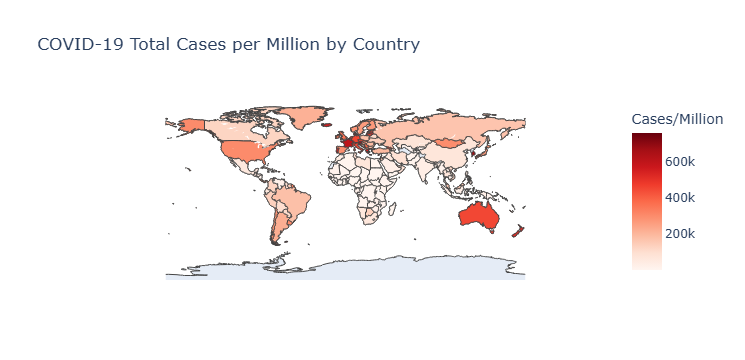

✅ Saved map1_total_cases.html


In [17]:
fig = px.choropleth(
    latest,
    locations='iso_code',
    color='total_cases_per_million',
    hover_name='location',
    hover_data={
        'total_cases': ':,.0f',
        'total_deaths': ':,.0f',
        'people_fully_vaccinated': ':,.0f'
    },
    color_continuous_scale='Reds',
    title='COVID-19 Total Cases per Million by Country'
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Cases/Million")
)
fig.show()
fig.write_html('visuals/map1_total_cases.html')
print("✅ Saved map1_total_cases.html")

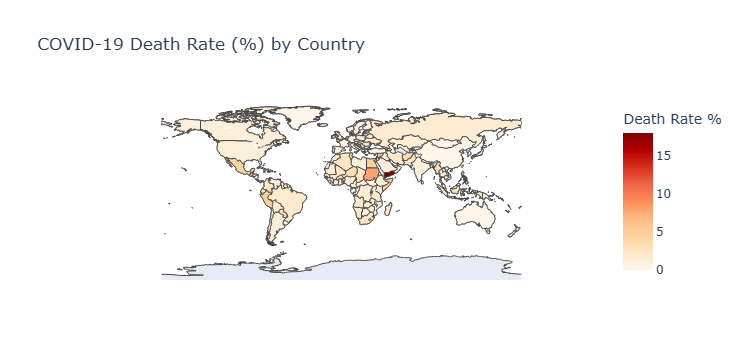

✅ Saved map2_death_rate.html


In [18]:
latest['death_rate'] = (latest['total_deaths'] / latest['total_cases'] * 100).round(2)

fig2 = px.choropleth(
    latest,
    locations='iso_code',
    color='death_rate',
    hover_name='location',
    hover_data={'death_rate': ':.2f', 'total_deaths': ':,.0f'},
    color_continuous_scale='OrRd',
    title='COVID-19 Death Rate (%) by Country'
)
fig2.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Death Rate %")
)
fig2.show()
fig2.write_html('visuals/map2_death_rate.html')
print("✅ Saved map2_death_rate.html")

In [19]:
# Monthly data to keep animation smooth
df_anim = df.copy()
df_anim['month'] = df_anim['date'].dt.to_period('M').astype(str)

monthly = df_anim.groupby(['location', 'iso_code', 'month']).agg(
    total_cases_per_million=('total_cases_per_million', 'max')
).reset_index()

monthly = monthly[monthly['total_cases_per_million'] > 0]
print("Animation frames:", monthly['month'].nunique())
monthly.head()

Animation frames: 56


,location,iso_code,month,total_cases_per_million
2,Afghanistan,AFG,2020-03,2.24
3,Afghanistan,AFG,2020-04,32.78
4,Afghanistan,AFG,2020-05,355.92
5,Afghanistan,AFG,2020-06,754.48
6,Afghanistan,AFG,2020-07,888.05


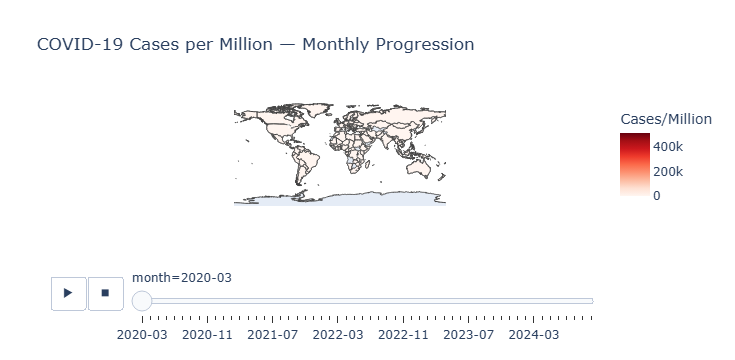

✅ Saved map3_animated.html


In [20]:
fig3 = px.choropleth(
    monthly,
    locations='iso_code',
    color='total_cases_per_million',
    hover_name='location',
    animation_frame='month',
    color_continuous_scale='Reds',
    range_color=[0, monthly['total_cases_per_million'].quantile(0.95)],
    title='COVID-19 Cases per Million — Monthly Progression'
)
fig3.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Cases/Million")
)
fig3.show()
fig3.write_html('visuals/map3_animated.html')
print("✅ Saved map3_animated.html")

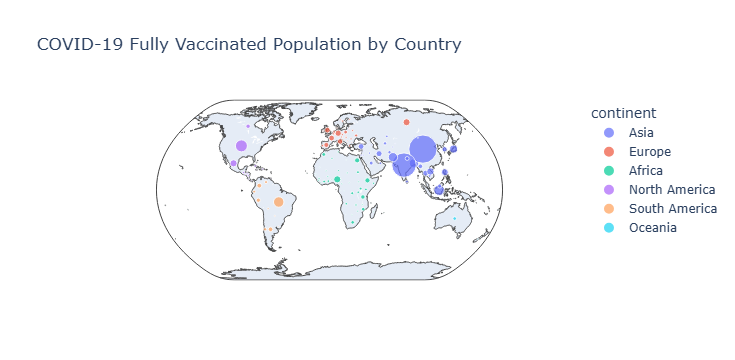

✅ Saved map4_vaccinations.html


In [21]:
vax_df = latest[latest['people_fully_vaccinated'] > 0].copy()

fig4 = px.scatter_geo(
    vax_df,
    locations='iso_code',
    size='people_fully_vaccinated',
    hover_name='location',
    hover_data={'people_fully_vaccinated': ':,.0f'},
    color='continent',
    projection='natural earth',
    title='COVID-19 Fully Vaccinated Population by Country'
)
fig4.show()
fig4.write_html('visuals/map4_vaccinations.html')
print("✅ Saved map4_vaccinations.html")